Adult Income EDA and Modeling

Project goal
You will explore the Adult Income dataset and build a simple model to predict whether income is greater than 50K.

Expected outcome
You will get a clean dataset, useful insights from EDA, and a baseline model with evaluation metrics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [5]:
DATA_PATH = "/content/adult_with_headers.xls"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Basic implementation

In [6]:
print("Data types:")
print(df.dtypes)

print("\nMissing NaN counts:")
print(df.isna().sum().sort_values(ascending=False).head(20))

obj_cols = df.select_dtypes(include=["object"]).columns
tmp = df[obj_cols].astype(str).apply(lambda s: s.str.strip())
q_counts = (tmp == "?").sum().sort_values(ascending=False)
print("\nMissing as '?' counts:")
print(q_counts[q_counts > 0].head(20))

print("\nNumeric summary:")
display(df.describe())


Data types:
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

Missing NaN counts:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Missing as '?' counts:
occupation        1843
workclass         1836
native_country     583
dtype: int64

Numeric summary:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Outcome missing value

In [7]:
df2 = df.copy()

obj_cols = df2.select_dtypes(include=["object"]).columns
df2[obj_cols] = df2[obj_cols].astype(str).apply(lambda s: s.str.strip())

for c in obj_cols:
    df2.loc[df2[c] == "?", c] = np.nan

num_cols = df2.select_dtypes(include=[np.number]).columns
cat_cols = df2.select_dtypes(include=["object"]).columns

for c in num_cols:
    df2[c] = df2[c].fillna(df2[c].median())

for c in cat_cols:
    df2[c] = df2[c].fillna(df2[c].mode()[0])

print("Total missing after handling:", int(df2.isna().sum().sum()))
df2.head()


Total missing after handling: 0


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Evaluate Scaling

In [8]:
X0 = df2.drop(columns=["income"]).copy()
y0 = df2["income"].copy()

num_cols0 = X0.select_dtypes(include=[np.number]).columns.tolist()

std_scaler0 = StandardScaler()
mm_scaler0 = MinMaxScaler()

X_std_preview = pd.DataFrame(std_scaler0.fit_transform(X0[num_cols0]), columns=num_cols0).head()
X_mm_preview = pd.DataFrame(mm_scaler0.fit_transform(X0[num_cols0]), columns=num_cols0).head()

print("Standard scaling preview:")
display(X_std_preview)

print("MinMax scaling preview:")
display(X_mm_preview)



Standard scaling preview:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


MinMax scaling preview:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.044302,0.800000,0.02174,0.0,0.397959
1,0.452055,0.048238,0.800000,0.00000,0.0,0.122449
2,0.287671,0.138113,0.533333,0.00000,0.0,0.397959
3,0.493151,0.151068,0.400000,0.00000,0.0,0.397959
4,0.150685,0.221488,0.800000,0.00000,0.0,0.397959


In [9]:
cat_cols0 = X0.select_dtypes(include=["object"]).columns.tolist()
cat_nunique = X0[cat_cols0].nunique().sort_values(ascending=False)

low_card_cols = cat_nunique[cat_nunique < 5].index.tolist()
high_card_cols = cat_nunique[cat_nunique >= 5].index.tolist()



Feature

In [10]:
X_fe = X0.copy()

if "capital-gain" in X_fe.columns and "capital-loss" in X_fe.columns:
    X_fe["net_capital"] = X_fe["capital-gain"] - X_fe["capital-loss"]

if "hours-per-week" in X_fe.columns:
    X_fe["hours_bucket"] = pd.cut(
        X_fe["hours-per-week"],
        bins=[0, 20, 40, 60, 100],
        labels=["0-20", "21-40", "41-60", "61-100"],
        include_lowest=True
    ).astype(str)

print("New features created:")
new_cols = [c for c in X_fe.columns if c not in X0.columns]
print(new_cols)
X_fe.head()


New features created:
[]


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


transformation

In [11]:
X_tf = X_fe.copy()

if "capital-gain" in X_tf.columns:
    before_skew = pd.Series(X_tf["capital-gain"]).skew()
    X_tf["capital_gain_log1p"] = np.log1p(X_tf["capital-gain"])
    after_skew = pd.Series(X_tf["capital_gain_log1p"]).skew()
    print("Skewness capital-gain before:", float(before_skew))
    print("Skewness capital-gain after log1p:", float(after_skew))
    print("Justification: capital-gain highly skewed hota hai, log1p extreme values compress karta hai aur model learning stable hoti hai.")
else:
    print("capital-gain column not found")


capital-gain column not found


Isolation forest outliers detection

In [12]:
num_cols_tf = X_tf.select_dtypes(include=[np.number]).columns.tolist()

sc_out = StandardScaler()
X_num_scaled = sc_out.fit_transform(X_tf[num_cols_tf])

iso = IsolationForest(n_estimators=300, contamination=0.02, random_state=42)
flag = iso.fit_predict(X_num_scaled)
mask_inlier = flag == 1

X_inlier = X_tf.loc[mask_inlier].reset_index(drop=True)
y_inlier = y0.loc[mask_inlier].reset_index(drop=True)

print("Total rows:", len(X_tf))
print("Outliers removed:", int((~mask_inlier).sum()))
print("Remaining rows:", len(X_inlier))



Total rows: 32561
Outliers removed: 652
Remaining rows: 31909


In [13]:
num_cols_in = X_inlier.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_in = X_inlier.select_dtypes(include=["object"]).columns.tolist()

std_scaler = StandardScaler()
X_std_num = pd.DataFrame(
    std_scaler.fit_transform(X_inlier[num_cols_in]),
    columns=[f"{c}__std" for c in num_cols_in]
)

cat_nunique_in = X_inlier[cat_cols_in].nunique()
low_card = cat_nunique_in[cat_nunique_in < 5].index.tolist()
high_card = cat_nunique_in[cat_nunique_in >= 5].index.tolist()

X_ohe = pd.get_dummies(X_inlier[low_card], prefix=low_card, drop_first=False)

ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_high = pd.DataFrame(
    ord_enc.fit_transform(X_inlier[high_card]),
    columns=[f"{c}__ord" for c in high_card]
)

X_final = pd.concat([X_std_num, X_ohe.reset_index(drop=True), X_high.reset_index(drop=True)], axis=1)

print("X_final shape:", X_final.shape)
X_final.head()


X_final shape: (31909, 15)


,age__std,fnlwgt__std,education_num__std,capital_gain__std,capital_loss__std,hours_per_week__std,sex_Female,sex_Male,workclass__ord,education__ord,marital_status__ord,occupation__ord,relationship__ord,race__ord,native_country__ord
0,0.047624,-1.071886,1.166605,0.681902,-0.192865,-0.025407,False,True,6.0,9.0,4.0,0.0,1.0,4.0,38.0
1,0.863163,-1.016236,1.166605,-0.232064,-0.192865,-2.272543,False,True,5.0,9.0,2.0,3.0,0.0,4.0,38.0
2,-0.026516,0.254597,-0.418829,-0.232064,-0.192865,-0.025407,False,True,3.0,11.0,0.0,5.0,1.0,4.0,38.0
3,1.085582,0.437778,-1.211546,-0.232064,-0.192865,-0.025407,False,True,3.0,1.0,2.0,5.0,0.0,2.0,38.0
4,-0.767914,1.433509,1.166605,-0.232064,-0.192865,-0.025407,True,False,3.0,9.0,2.0,9.0,5.0,2.0,4.0


Correlation matrix

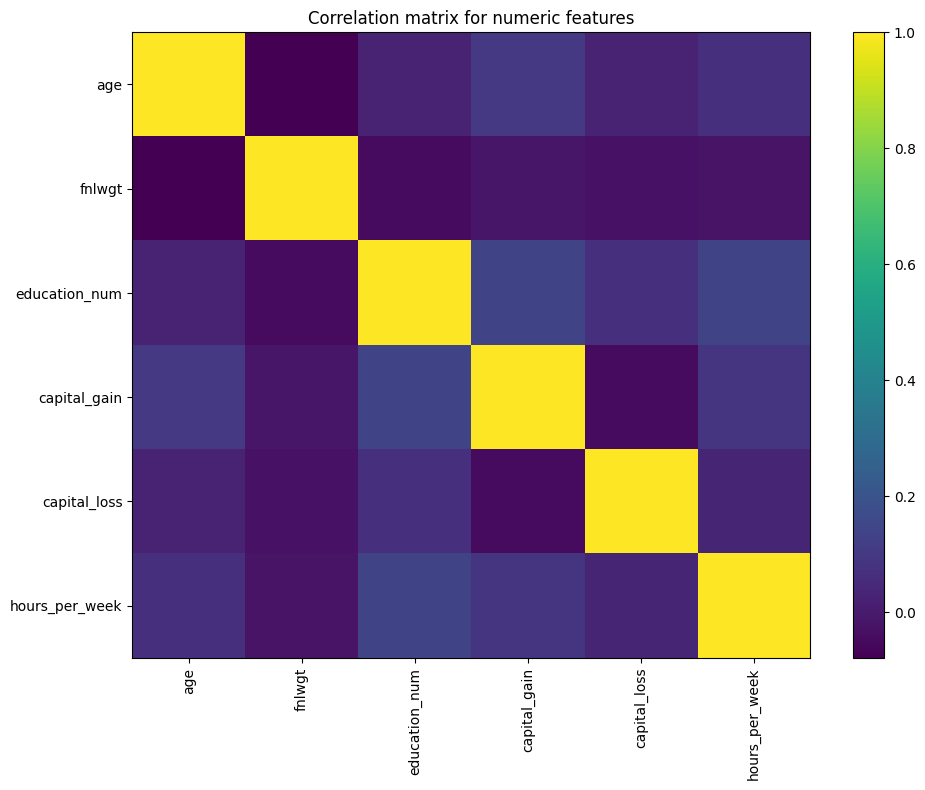

In [14]:
corr = X_inlier.select_dtypes(include=[np.number]).corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation matrix for numeric features")
plt.tight_layout()
plt.show()



PPS try

In [15]:
score_method = "mutual_information"
score_table = None

try:
    import ppscore as pps
    score_method = "pps"
    df_pps = pd.concat([X_inlier.copy(), y_inlier.rename("income")], axis=1)
    m = pps.matrix(df_pps)
    score_table = (
        m[(m["y"] == "income") & (m["x"] != "income")]
        .sort_values("ppscore", ascending=False)
        .head(15)[["x", "ppscore"]]
        .rename(columns={"x": "feature", "ppscore": "score"})
    )
except Exception as e:
    y_bin = (y_inlier.astype(str).str.contains(">50K")).astype(int)
    mi = mutual_info_classif(X_final, y_bin, random_state=42)
    score_table = (
        pd.DataFrame({"feature": X_final.columns, "score": mi})
        .sort_values("score", ascending=False)
        .head(15)
    )

print("Feature relationship scoring method used:", score_method)
display(score_table)



Feature relationship scoring method used: mutual_information


,feature,score
12,relationship__ord,0.112970
10,marital_status__ord,0.109176
3,capital_gain__std,0.075230
0,age__std,0.064937
9,education__ord,0.061072
2,education_num__std,0.060712
11,occupation__ord,0.048681
5,hours_per_week__std,0.040559
4,capital_loss__std,0.032586
1,fnlwgt__std,0.031316


Model check

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_inlier, test_size=0.2, random_state=42, stratify=y_inlier
)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, pred))
print("Classification report:")
print(classification_report(y_test, pred))


Accuracy: 0.8246631150109683
Confusion matrix:
[[4645  257]
 [ 862  618]]
Classification report:
              precision    recall  f1-score   support

       <=50K       0.84      0.95      0.89      4902
        >50K       0.71      0.42      0.52      1480

    accuracy                           0.82      6382
   macro avg       0.77      0.68      0.71      6382
weighted avg       0.81      0.82      0.81      6382



I worked with the Adult Income dataset.
I replaced “?” with missing values.
I filled missing numeric values using the median and filled missing categorical values using the mode.

I tested two scaling methods, StandardScaler and MinMaxScaler.
I encoded categorical features using One Hot Encoding for low category columns and Ordinal Encoding for high category columns.

I created two simple features, net_capital and hours_bucket.
I applied log1p on capital_gain because it was highly skewed.
I handled outliers using Isolation Forest.

For feature relevance, PPS did not install properly in Colab, so I used Mutual Information instead.
Finally, I trained a Logistic Regression model and reported accuracy, confusion matrix, and the classification report.


**when I install PPS then, PPS dependency conflict in the colab, after that use mutual information**